Import packages

In [1]:
import pandas as pd
import numpy as np
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
import altair as alt
import pickle
import gdown
import matplotlib.pyplot as plt
import folium
from geopy.geocoders import Nominatim
import openrouteservice
import time
import seaborn as sns
import openpyxl
import scipy.stats as stats
import requests
from pandas_datareader import wb
from prophet import Prophet
from sklearn.metrics import mean_squared_log_error

c:\Users\m.muller\.pyenv\pyenv-win\versions\3.10.11\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Get scoped sales file en features toevoegen

In [2]:
with open('C:\\Users\\m.muller\\Documents\\Python\\Projects\\Supermarket CFGS\\Data\\supermarket_scope_dairy.pkl', 'rb') as pickle_file:
    dc_scoped_df = pickle.load(pickle_file)
    sales_history = dc_scoped_df['df_processed']

sales_history['weight'] = np.where(sales_history['perishable'] == 1, 1.25, 1.0)
sales_history['weekday'] = sales_history['date'].dt.dayofweek
sales_history['quarter'] = sales_history['date'].dt.quarter

print(sales_history.head())
print()
print(sales_history.shape)

  onpromotion    month family   city      state type_store type_holiday  \
0         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
1         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
2         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
3         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
4         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   

       locale locale_name description transferred       date        id  \
0  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02  16375666   
1  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02  16375669   
2  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02  16375677   
3  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02  16375693   
4  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02  16375701   

   store_nbr  item_nbr  unit_sales  day  class  perishable  cluster  \
0         44  122095.0         9.

Artikelnummer verwijderen en verkopen per winkel per dag optellen

In [6]:
# Verwijder item_nbr en de originele unit_sales
df_zonder_artnr = sales_history.drop(columns=['unit_sales', 'id', 'class', 'cluster'])
df_zonder_artnr['item_nbr'] = 'all'

# Bereken totaal unit_sales per date & store_nbr
totaal = (
    sales_history.groupby(['date', 'store_nbr'])['unit_sales']
      .sum()
      .reset_index()
)

# Merge totaal terug
df_zonder_artnr = df_zonder_artnr.merge(totaal, on=['date', 'store_nbr'], how='left')
df_zonder_artnr = df_zonder_artnr.drop_duplicates()
df_zonder_artnr = df_zonder_artnr.reset_index(drop=True)

print(df_zonder_artnr.head())
print()
print(df_zonder_artnr.shape)

  onpromotion    month family   city      state type_store type_holiday  \
0         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
1         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
2         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
3         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
4         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   

       locale locale_name description transferred       date  store_nbr  \
0  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02         44   
1  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02         45   
2  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02         46   
3  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02         47   
4  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02         48   

  item_nbr  day  perishable  oil_price  temperature_2m_max  salary_payment  \
0      all    2     

Neem 1 artikel en 1 store

   onpromotion    month family   city      state type_store type_holiday  \
0          NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
8          NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
16         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
24         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   
32         NaN  2014-01  DAIRY  Quito  Pichincha          A   NO_HOLIDAY   

        locale locale_name description transferred       date  store_nbr  \
0   NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-02         44   
8   NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-03         44   
16  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-04         44   
24  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-05         44   
32  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY  NO_HOLIDAY 2014-01-06         44   

   item_nbr  day  perishable  oil_price  temperature_2m_max  salary_payment  \
0      

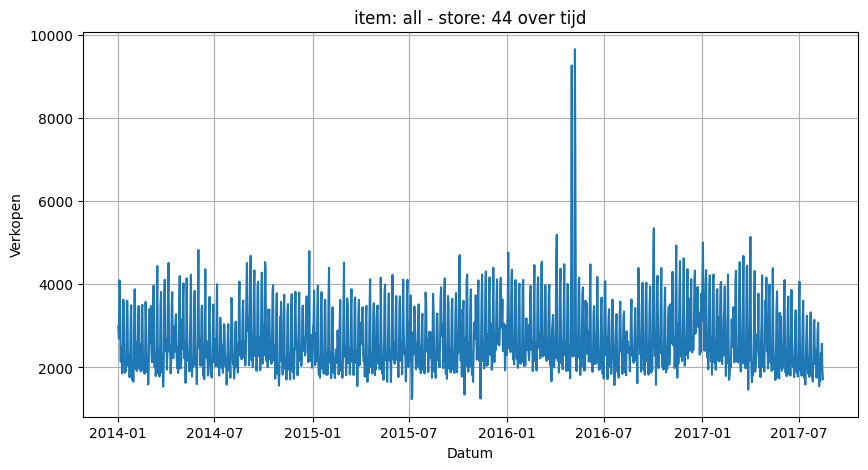

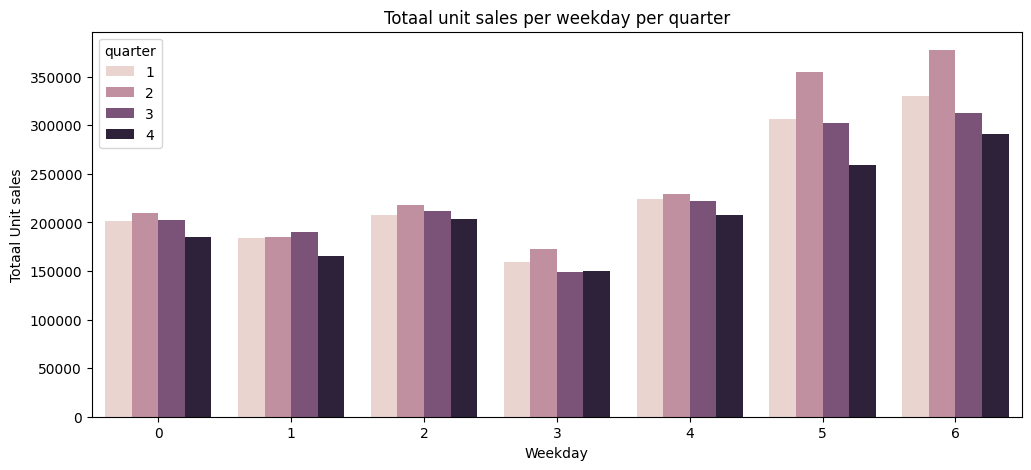

In [13]:
selected_item = 'all'
selected_store = 44

#Filter de data
#df_filtered = sales_history[(sales_history["item_nbr"] == selected_item) & (sales_history["store_nbr"] == selected_store)]
df_filtered = df_zonder_artnr[(df_zonder_artnr["item_nbr"] == selected_item) & (df_zonder_artnr["store_nbr"] == selected_store)]

print(df_filtered.head())

# Zorg dat data op datum gesorteerd is
df_filtered = df_filtered.sort_values("date")

# Plot de grafiek
plt.figure(figsize=(10, 5))
plt.plot(df_filtered["date"], df_filtered["unit_sales"])
plt.title(f"item: {selected_item} - store: {selected_store} over tijd")
plt.xlabel("Datum")
plt.ylabel("Verkopen")
plt.grid(True)
plt.show()

#fuguur per weekdag
pivot = (
    df_filtered.groupby(['weekday', 'quarter'])['unit_sales']
      .sum()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=pivot,
    x='weekday',
    y='unit_sales',
    hue='quarter',
    ax=ax
)
ax.set_title('Totaal unit sales per weekday per quarter')
ax.set_xlabel('Weekday')
ax.set_ylabel('Totaal Unit sales')
plt.show()

Baseline model uitvoeren

In [9]:
# Parameters
lookback_days = 28
group_cols = ['item_nbr']
test_df  = df_filtered[df_filtered['date'] >= '2017-01-01']

# Generate full-range predictions
start_date = test_df['date'].min() + pd.Timedelta(days=lookback_days)
end_date = test_df['date'].max()
prediction_dates = pd.date_range(start=start_date, end=end_date)

all_preds = []

for date in prediction_dates:
    cutoff = date - pd.Timedelta(days=1)
    lookback_start = cutoff - pd.Timedelta(days=lookback_days)

    history = test_df[(test_df['date'] > lookback_start) & (test_df['date'] <= cutoff)]

    for (item,), group in history.groupby(group_cols):
        weekday_avg = group.groupby(group['date'].dt.dayofweek)['unit_sales'].mean()
        weekday_avg = weekday_avg.reindex(range(7), fill_value=0)
        predicted = weekday_avg[date.dayofweek]

        all_preds.append({
            'date': date,
            'store_nbr': selected_store,
            'item_nbr': item,
            'predicted_sales': predicted
        })

# Create predictions DataFrame
baseline_df = pd.DataFrame(all_preds)

# Ensure matching dtypes
test_df['item_nbr'] = test_df['item_nbr'].astype(str)
baseline_df['item_nbr'] = baseline_df['item_nbr'].astype(str)

# Merge actuals with predictions
merged_all = pd.merge(
    test_df,
    baseline_df,
    on=['date', 'store_nbr', 'item_nbr'],
    how='left'
)

# Fill missing predictions
merged_all['predicted_sales'] = merged_all['predicted_sales'].fillna(0)


C:\Users\m.muller\AppData\Local\Temp\ipykernel_22084\1932316489.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['item_nbr'] = test_df['item_nbr'].astype(str)


Asym MSAE voor baseline

In [10]:
# Asymmetrie-factor
alpha = 2  # overschatting telt 2 zo zwaar

# Bereken fout
def asymmetric_error(row):
    if row['predicted_sales'] > row['unit_sales']:  # overschatting
        return alpha * abs(row['unit_sales'] - row['predicted_sales']) * row['weight']
    else:  # onderschatting
        return abs(row['unit_sales'] - row['predicted_sales']) * row['weight']

merged_all['asym_error'] = merged_all.apply(asymmetric_error, axis=1)

# Bereken weighted mean
asymmetric_wmae = merged_all['asym_error'].sum() / merged_all['weight'].sum()
print("Asymmetric WMAE:", asymmetric_wmae)


Asymmetric WMAE: 809.8723480156943


Prophet model toepassen op train test data en rmsle / nwrmsle berekenen

In [11]:

all_forecasts = []


#split in train en testdata
train_df = df_filtered[df_filtered['date'] < '2017-01-01']
test_df  = df_filtered[df_filtered['date'] >= '2017-01-01']

#forecasting via prophet
df_prophet_train = train_df.rename(columns={'date': 'ds', 'unit_sales': 'y'})
df_prophet_test = test_df.rename(columns={'date': 'ds', 'unit_sales': 'y'})

model = Prophet()
model.fit(df_prophet_train)

forecast = model.predict(df_prophet_test)

print(forecast.head())
print()

# Join voorspelling en echte waarden
forecast_test = forecast.set_index('ds').join(
    test_df.set_index('date')[['unit_sales', 'weight']], how='inner'
)

# Asymmetrie-factor
alpha = 2  # overschatting telt 2 zo zwaar

def asymmetric_error(row):
    if row['yhat'] > row['unit_sales']:  # overschatting
        return alpha * abs(row['unit_sales'] - row['yhat']) * row['weight']
    else:  # onderschatting
        return abs(row['unit_sales'] - row['yhat']) * row['weight']

forecast_test['asym_error'] = forecast_test.apply(asymmetric_error, axis=1)

# Bereken weighted mean
asymmetric_wmae = forecast_test['asym_error'].sum() / forecast_test['weight'].sum()
print("Asymmetric WMAE (Prophet):", asymmetric_wmae)



11:26:51 - cmdstanpy - INFO - Chain [1] start processing
11:26:52 - cmdstanpy - INFO - Chain [1] done processing


          ds        trend   yhat_lower   yhat_upper  trend_lower  trend_upper  \
0 2017-01-02  2808.855894  2062.756806  3306.858530  2808.855894  2808.855894   
1 2017-01-02  2808.855894  1997.114927  3308.259695  2808.855894  2808.855894   
2 2017-01-03  2808.426247  1760.235699  3132.495353  2808.426247  2808.426247   
3 2017-01-03  2808.426247  1810.759544  3105.710781  2808.426247  2808.426247   
4 2017-01-04  2807.996601  2139.401400  3361.917074  2807.996601  2807.996601   

   additive_terms  additive_terms_lower  additive_terms_upper      weekly  \
0     -124.120547           -124.120547           -124.120547 -332.676139   
1     -124.120547           -124.120547           -124.120547 -332.676139   
2     -367.590457           -367.590457           -367.590457 -555.823741   
3     -367.590457           -367.590457           -367.590457 -555.823741   
4      -48.465141            -48.465141            -48.465141 -216.354805   

   weekly_lower  weekly_upper      yearly  yearly_

Grafiek afwijkingen

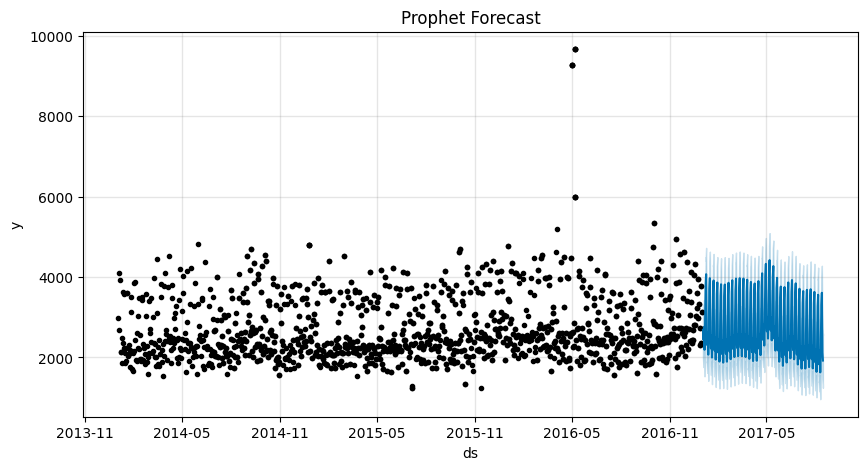

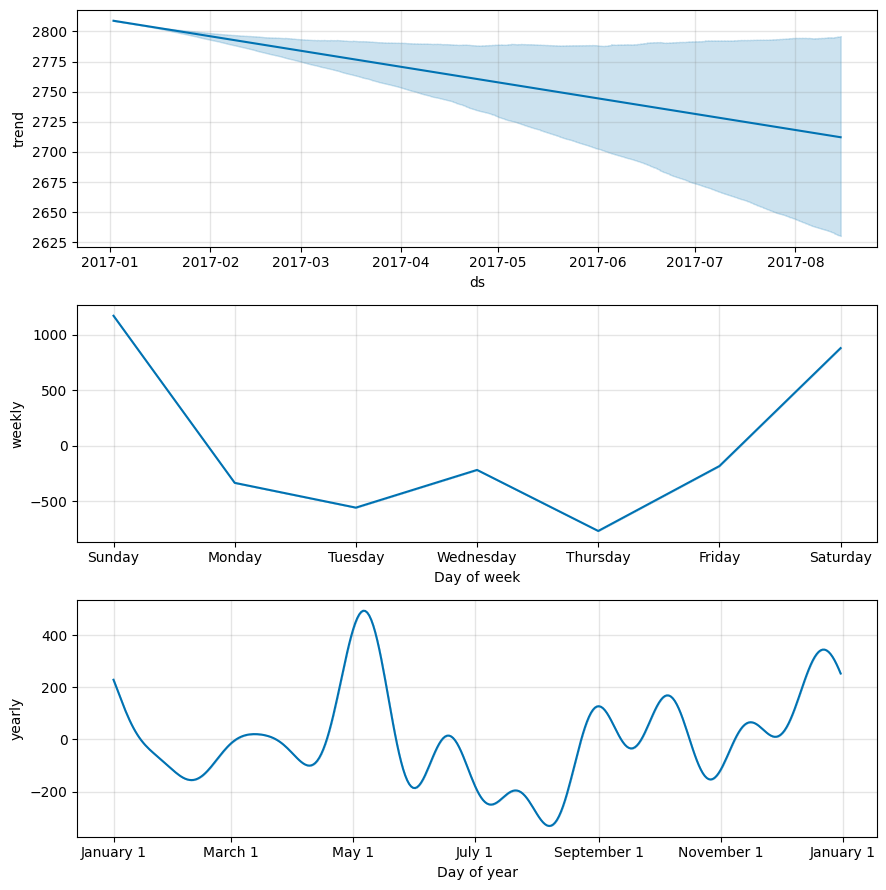

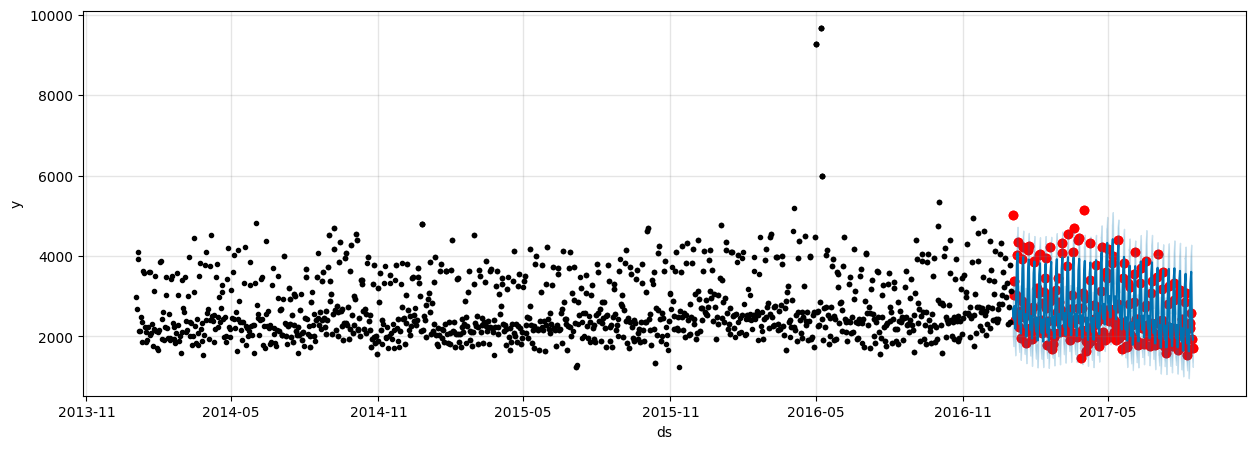

In [12]:
#figuur met voorspellingen
fig, ax = plt.subplots(figsize=(10, 5))
fig = model.plot(forecast, ax=ax)
ax.set_title('Prophet Forecast')
plt.show()

#Figuur trends
fig = model.plot_components(forecast)
plt.show()

#forecast and actuals
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(df_prophet_test['ds'], df_prophet_test['y'], color='r')
fig = model.plot(forecast, ax=ax)


XXXX